# Title + Objective (Markdown)

Define problem: forest cover type prediction

Define what you’ll verify: data quality + target distribution + sanity

# EcoType — Data Understanding

## Objective

The goal of this project is to predict the **forest cover type** of a land patch using cartographic, topographic, and soil-related features.
This is a **multiclass classification problem**, where the target variable is the forest cover category.

In this section, the focus is not on model building yet.
The aim is to first understand the dataset and verify whether it is ready for further preprocessing, EDA, and training.

## What will be verified

In this phase, we will check:

- **Data quality**
  - dataset shape
  - column names and data types
  - missing values
  - duplicate records
  - basic structural consistency

- **Target distribution**
  - count of each forest cover class
  - percentage share of each class
  - whether class imbalance exists

- **Basic sanity checks**
  - minimum and maximum values of important numerical features
  - whether values fall into expected logical ranges
  - whether any suspicious or clearly invalid values are present

This step helps build confidence in the dataset before moving to preprocessing and modeling.

# Imports + Config (Code)

Imports (pandas/numpy/matplotlib)

Set pandas display options

Define paths: RAW_PATH, REPORT_DIR

Set SEED

In [2]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
project_root = Path.cwd().parent
data_file = project_root/"data"/"interim"/"forest_cover_interim.csv"
report_dir = project_root/"reports"/"data_quality"

In [4]:
problem_statement = """
Predict the forest cover type (7 classes) from cartographic,
topographic, and soil-related features.
"""

target_definition = """
Target column: cover_type
Task type: Multiclass classification
Number of target classes expected: 7
"""

print(problem_statement)
print(target_definition)


Predict the forest cover type (7 classes) from cartographic,
topographic, and soil-related features.


Target column: cover_type
Task type: Multiclass classification
Number of target classes expected: 7



# Load Raw Data (Code)

Read dataset from data/raw/

Print shape

Print first 5 rows

Print last 5 rows

In [5]:
df = pd.read_csv(data_file)
df.head()

,elevation,aspect,slope,horizontal_distance_to_hydrology,vertical_distance_to_hydrology,horizontal_distance_to_roadways,hillshade_9am,hillshade_noon,hillshade_3pm,horizontal_distance_to_fire_points,cover_type,wilderness_area,soil_type
0,2596,51,3,258,0,510,221,232,148,6279,Aspen,1,29
1,2590,56,2,212,-6,390,220,235,151,6225,Aspen,1,29
2,2804,139,9,268,65,3180,234,238,135,6121,Lodgepole Pine,1,12
3,2785,155,18,242,118,3090,238,238,122,6211,Lodgepole Pine,1,30
4,2595,45,2,153,-1,391,220,234,150,6172,Aspen,1,29


In [6]:
df.tail()

,elevation,aspect,slope,horizontal_distance_to_hydrology,vertical_distance_to_hydrology,horizontal_distance_to_roadways,hillshade_9am,hillshade_noon,hillshade_3pm,horizontal_distance_to_fire_points,cover_type,wilderness_area,soil_type
145885,2834,88,8,376,44,2552,232,227,128,1595,Lodgepole Pine,1,29
145886,2832,68,4,390,44,2522,224,231,142,1572,Lodgepole Pine,1,29
145887,2829,80,7,390,33,2492,229,228,133,1550,Lodgepole Pine,1,29
145888,2826,121,7,379,30,2462,232,234,135,1528,Lodgepole Pine,1,29
145889,2823,132,12,371,27,2432,239,234,123,1506,Lodgepole Pine,1,1


In [7]:
print("Shape: ", df.shape)

Shape:  (145890, 13)


# Column Inventory (Code)

Print columns list

Print df.info()

Print dtypes count (how many numeric/cat)

In [8]:
df.columns

Index(['elevation', 'aspect', 'slope', 'horizontal_distance_to_hydrology',
       'vertical_distance_to_hydrology', 'horizontal_distance_to_roadways',
       'hillshade_9am', 'hillshade_noon', 'hillshade_3pm',
       'horizontal_distance_to_fire_points', 'cover_type', 'wilderness_area',
       'soil_type'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145890 entries, 0 to 145889
Data columns (total 13 columns):
 #   Column                              Non-Null Count   Dtype 
---  ------                              --------------   ----- 
 0   elevation                           145890 non-null  int64 
 1   aspect                              145890 non-null  int64 
 2   slope                               145890 non-null  int64 
 3   horizontal_distance_to_hydrology    145890 non-null  int64 
 4   vertical_distance_to_hydrology      145890 non-null  int64 
 5   horizontal_distance_to_roadways     145890 non-null  int64 
 6   hillshade_9am                       145890 non-null  int64 
 7   hillshade_noon                      145890 non-null  int64 
 8   hillshade_3pm                       145890 non-null  int64 
 9   horizontal_distance_to_fire_points  145890 non-null  int64 
 10  cover_type                          145890 non-null  object
 11  wilderness_area                     145

In [10]:
display(df.dtypes.to_frame("dtype"))

,dtype
elevation,int64
aspect,int64
slope,int64
horizontal_distance_to_hydrology,int64
vertical_distance_to_hydrology,int64
horizontal_distance_to_roadways,int64
hillshade_9am,int64
hillshade_noon,int64
hillshade_3pm,int64
horizontal_distance_to_fire_points,int64


# Missing Values Scan (Code)

Compute missing count per column

Compute missing percentage per column

Sort descending

Decide: are there any missing values?

In [11]:
missing_df = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_pct": (df.isnull().mean() * 100).round(2)
}).sort_values("missing_count", ascending = False)

display(missing_df)

,missing_count,missing_pct
elevation,0,0.0
aspect,0,0.0
slope,0,0.0
horizontal_distance_to_hydrology,0,0.0
vertical_distance_to_hydrology,0,0.0
horizontal_distance_to_roadways,0,0.0
hillshade_9am,0,0.0
hillshade_noon,0,0.0
hillshade_3pm,0,0.0
horizontal_distance_to_fire_points,0,0.0


# Duplicate Rows Check

Count duplicates

If duplicates exist:

print how many

show sample duplicates

In [12]:
duplicate_count = df.duplicated().sum()
print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


# Target Column Check (Code)

Confirm target exists

Print unique target values

Print target counts

Print target % distribution

Identify imbalance severity

In [13]:
class_counts = df["cover_type"].value_counts().sort_index()
class_pct = (df["cover_type"].value_counts(normalize = True).sort_index() * 100).round(2)

class_dist = pd.DataFrame({
    "count": class_counts,
    "percent": class_pct
})

display(class_dist)

,count,percent
cover_type,,
Aspen,3069,2.10
Cottonwood/Willow,2160,1.48
Douglas-fir,2160,1.48
Krummholz,2160,1.48
Lodgepole Pine,103071,70.65
Ponderosa Pine,2160,1.48
Spruce/Fir,31110,21.32


# Numeric Feature Sanity (Code)

df.describe().T

Check min/max for suspicious ranges

Flag:

any negative where shouldn’t be

extreme outliers

In [14]:
numeric_summary = df.describe().T[["min", "max", "mean", "std"]]
display(numeric_summary)

,min,max,mean,std
elevation,1863.0,3849.0,2874.458949,210.801279
aspect,0.0,360.0,141.127418,107.719296
slope,0.0,61.0,11.925574,6.319326
horizontal_distance_to_hydrology,0.0,1343.0,251.824738,192.473899
vertical_distance_to_hydrology,-146.0,554.0,34.554322,41.215776
horizontal_distance_to_roadways,0.0,7117.0,3313.827541,1687.779953
hillshade_9am,0.0,254.0,217.368106,21.590298
hillshade_noon,99.0,254.0,224.874748,16.084851
hillshade_3pm,0.0,248.0,139.788203,31.311690
horizontal_distance_to_fire_points,0.0,7173.0,3044.958105,1761.882341


# Quick Visuals (Code)

Plot target distribution bar chart

Plot 3–5 important numeric histograms (if large)

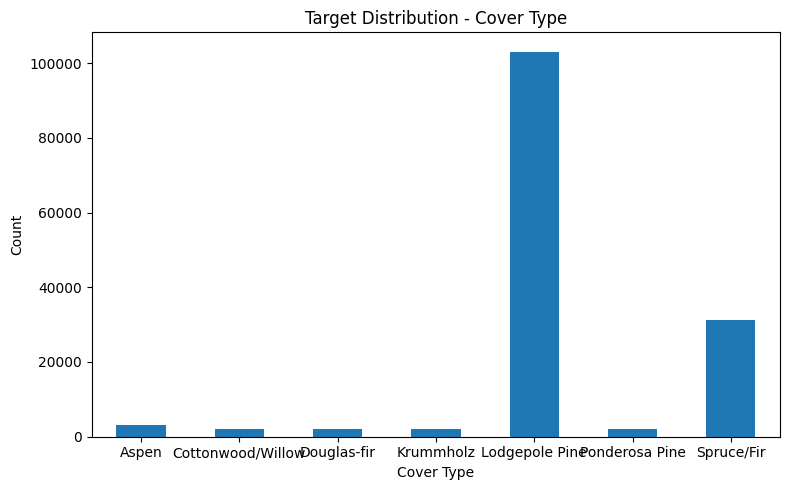

In [15]:
# Target distribution bar chart

target_counts = df["cover_type"].value_counts().sort_index()

plt.figure(figsize=(8, 5))
target_counts.plot(kind="bar")
plt.title("Target Distribution - Cover Type")
plt.xlabel("Cover Type")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

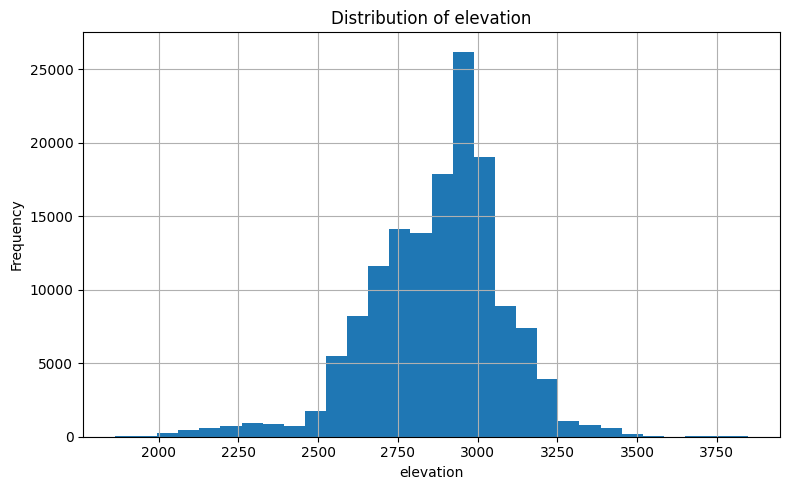

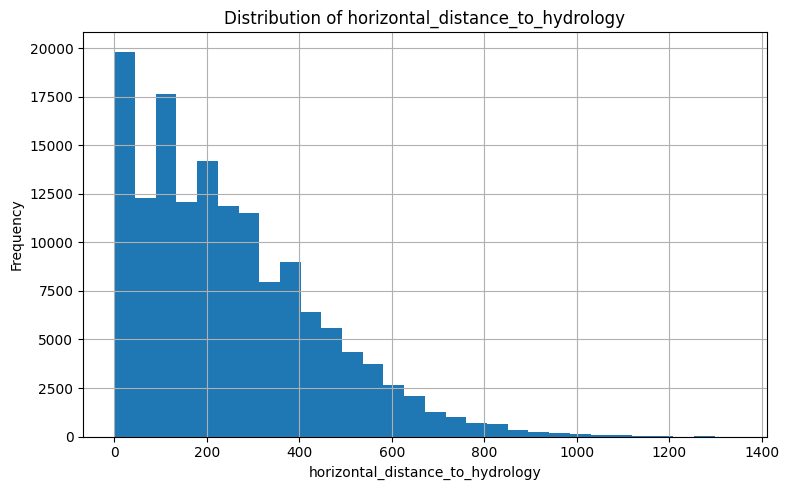

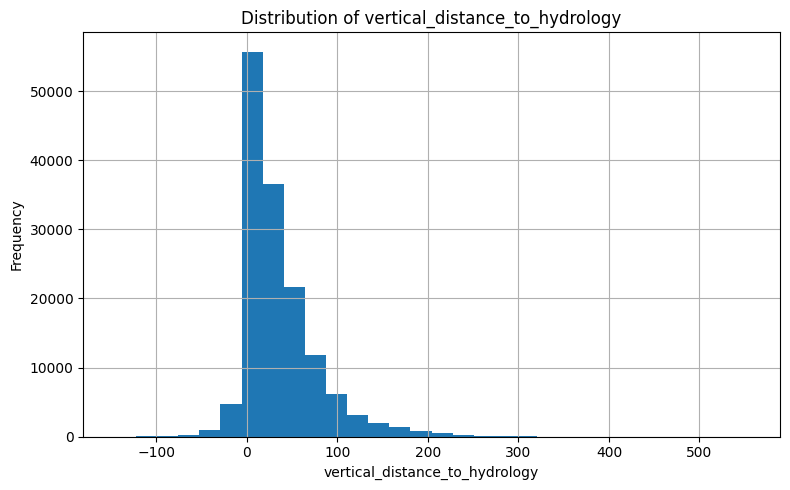

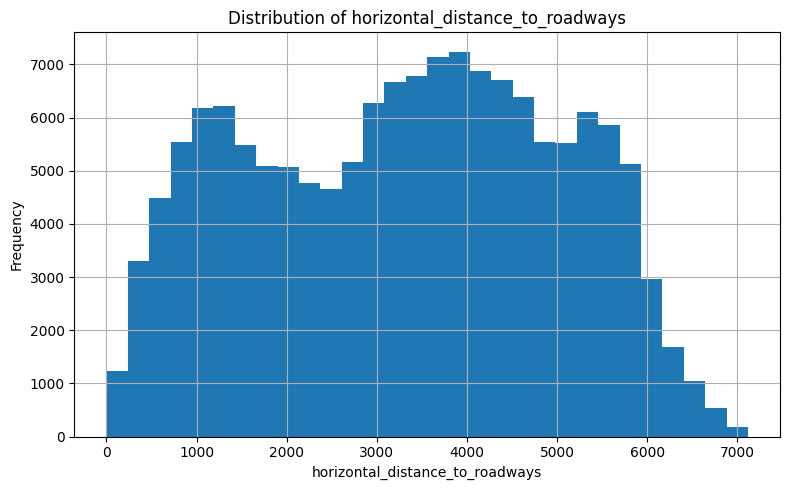

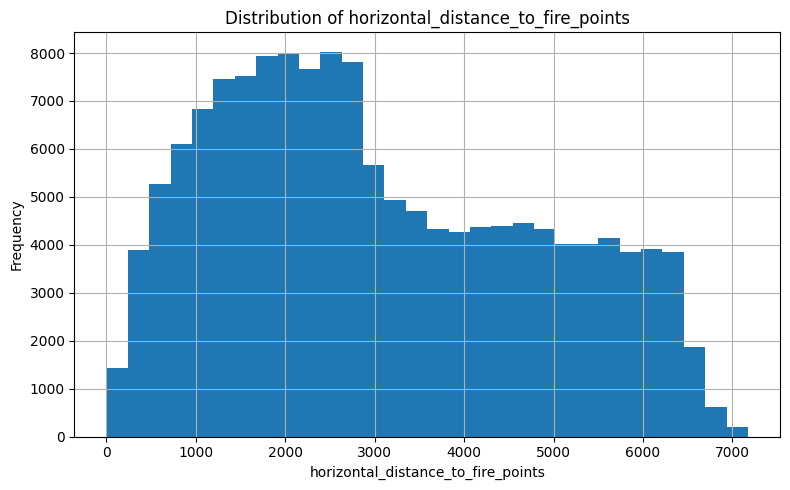

In [17]:
# Histograms for important numeric features
numeric_cols = [
    "elevation",
    "horizontal_distance_to_hydrology",
    "vertical_distance_to_hydrology",
    "horizontal_distance_to_roadways",
    "horizontal_distance_to_fire_points"
]

for col in numeric_cols:
    if col in df.columns:
        plt.figure(figsize=(8, 5))
        df[col].hist(bins=30)
        plt.title(f"Distribution of {col}")
        plt.xlabel(col)
        plt.ylabel("Frequency")
        plt.tight_layout()
        plt.show()

# Save “Data Understanding” Report (Code)

Save:

class distribution table → reports/data_quality/class_distribution.csv

missing values table → reports/data_quality/missing_values.csv

basic summary → reports/data_quality/column_summary.md

In [16]:
missing_df.to_csv(report_dir/"missing_values_summary.csv")
class_dist.to_csv(report_dir/"class_distribution.csv")
numeric_summary.to_csv(report_dir/"numeric_min_max_summary.csv")

summary_text = f"""
# Data Quality Summary

## Shape
Rows: {df.shape[0]}
Columns: {df.shape[1]}

## Missing Values
Total missing values: {int(df.isnull().sum().sum())}

## Duplicate Rows
Duplicate rows: {int(df.duplicated().sum())}

## Target
Target column: cover_type
Unique target classes: {df['cover_type'].nunique()}
"""

(report_dir/"data_quality_summary.md").write_text(summary_text, encoding = "utf-8")

print("Reports saved to reports/data_quality/")

Reports saved to reports/data_quality/


# Notes + Decisions (Markdown)

What you learned

What will be cleaned later

Split strategy decision (stratified)